In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
from scipy.integrate import quad
import math
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# Fridge Details

In [3]:
from library.fridges import TEMP_STAGES, FRIDGE_LIBRARY
# Assuming XLD1000sl
# We will use the operating temperatures and cable lengths corresponding to an XLD1000sl fridge
fridge = FRIDGE_LIBRARY["XLD1000SL"]
cooling_power_budget = fridge["cooling_power"]
operating_temp = fridge["temp"]
flange_separation = fridge["lengths"]

# Thermal Conductivity

Effect of neutron irradiation on the density of low-energy excitations in vitreous silica


<img src="./silica.png"
     width="400" height="400"
     style="background-color: white;"/>

In [4]:
# Silica Fiber Thermal Conductivity
# Based on data from 
# Smith, Terry Lee, P. J. Anthony, and A. C. Anderson. "Effect of neutron irradiation on the density of low-energy excitations in vitreous silica." Physical Review B 17.12 (1978): 4997.
t_data = np.array([0.1, 1.0, 4, 50, 100, 400])
g_data = np.array([3E-6, 1.5E-4, 1E-3, 3E-3, 5E-3, 2E-2])* 1E2 # W per cm-Kelvin * 1E2 ->  W per m-Kelvin

In [5]:
from library.cables import fiber_thermal_conductivity

# Generate data points
x_vals = np.geomspace(0.08, 400, num=100)
y_vals = fiber_thermal_conductivity(x_vals)

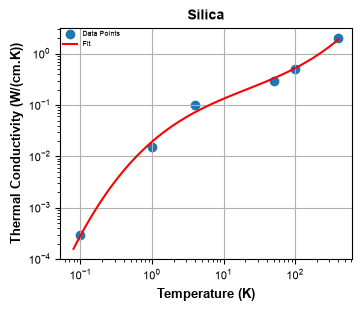

In [6]:
# Plot datapoints

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)

ax.scatter(t_data, g_data, label='Data Points')
ax.loglog(x_vals, y_vals, color='red', label='Fit')
ax.set_title("Silica", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Thermal Conductivity (W/(cm.K))', fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)
    
ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.grid(True)

plt.savefig(f"./silica_thermal_conductivity.png",dpi=600)
plt.show()

In [7]:
# PHL for one strand of fiber
def calc_PHL(cable_length, cable_diam, T_lo, T_hi): # cable lengths in cm
    # Integrate cu_thermal_conductivity(T) from T_hi to T_lo
    result, error = quad(fiber_thermal_conductivity, T_lo, T_hi)
    # Get cross sectional area of wire 
    area = np.pi * (cable_diam/2)**2
    # For 3 wires per amplifier
    return result * (area/(cable_length*1E-2)) #cable length is in cm

# Assuming AWG30 wire
cable_diam = 250E-6 # m 2021lecocqControlReadoutSuperconducting

print("PHL for Silica")
for temp_stage in TEMP_STAGES[1:]:
    # get cable length
    cable_length = flange_separation[temp_stage] # cm
    
    # get operating temperatures
    current_temp_stage_idx = TEMP_STAGES.index(temp_stage)
    if current_temp_stage_idx > 0:
        prev_temp_stage = TEMP_STAGES[current_temp_stage_idx - 1]
    T_lo = operating_temp[temp_stage]
    T_hi = operating_temp[prev_temp_stage]
    
    PHL = calc_PHL(cable_length, cable_diam, T_lo, T_hi)
    
    print(f"{temp_stage}:\t {PHL:.4e} W")

PHL for Silica
50K:	 3.4030e-05 W
4K:	 1.1305e-06 W
Still:	 1.7976e-08 W
CP:	 4.3998e-09 W
MXC:	 2.1867e-11 W
